# Cross Sectional Momentum Portfolio 
### By Danny Salib 

### Getting Started

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from system.config import Config
from system.state import State

In [2]:
plt.style.use('classic')
plt.rcParams['lines.linewidth'] = 1.5

### Creating configuration and state machine 

In [3]:
# TODO explain what you mean here

In [4]:
from system.strategy import SALIB_MOMENTUM_STRATEGY

cfg = Config(
    trade_freq='W-MON',
    skip_days=21,
    nasdaq_n_stocks=-1,
    n_basket=25,
    strategy=SALIB_MOMENTUM_STRATEGY,
    leverage=True,
)
state = State()

### Stock Selection Aalysis

##### Universe implementation 
At first I was using the SP500 stocks as my universe, but I want to take a more academic approach. The problem is, academics don't care about tradeable stocks, and care more about broad stroke anomlies that may exist in the world. To bridge this gap, I'll swap the SP500 stocks for a larger universe: NASDAQ

In [5]:
# TODO talk about this

### Downloading Data

In [6]:
# TODO explain what download_data is doing cuz it's pretty cool

### Creating Signals for DUAL Momentum

### Building the Signal 

# Visualizations

Cache file not found. Downloading full history.
[*********************100%***********************]  1881 of 1881 completed
Cache file not found. Downloading full history.
[*********************100%***********************]  1 of 1 completed
Cache file not found. Downloading full history.
[*********************100%***********************]  1 of 1 completed
Cache file not found. Downloading full history.
[*********************100%***********************]  1 of 1 completed
100%|██████████| 1572/1572 [00:04<00:00, 342.04it/s]
c:\Users\Danny\Documents\projects\trading_algos\csm\system\signals.py:275: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return ((fast_vol / slow_vol) > threshold).shift(1).fillna(False)
Portfolio return is NaN on 42 day(s) while holding a non-zero posi

Report saved to: ./reports/salib_momentum.pdf


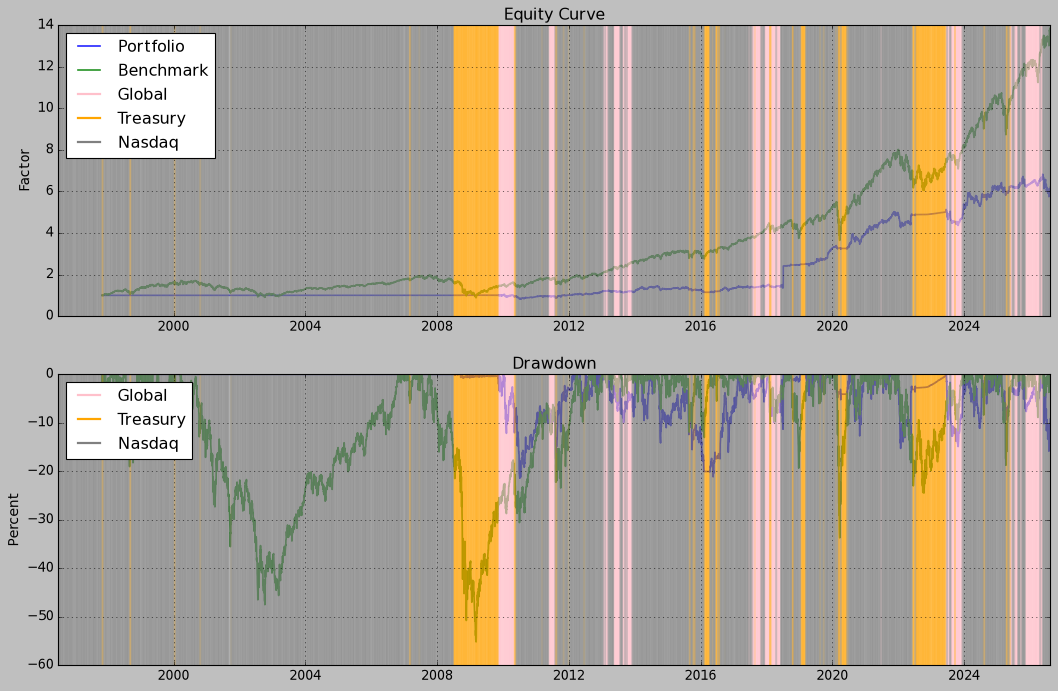

In [7]:
from system.visualize import plot_portfolio_equity, export_report_pdf
from matplotlib.lines import Line2D

fig = plot_portfolio_equity(cfg, state)

in_glbl = state.signal_df[state.signal_df['glbl'].eq(1)].index
in_treasury = state.signal_df[state.signal_df['tbill'].eq(1)].index
in_nasdaq = state.signal_df.index.difference(in_glbl).difference(in_treasury)

from matplotlib.lines import Line2D

for ax in fig.axes:
    # Your existing plots already have legend entries
    handles, labels = ax.get_legend_handles_labels()

    # Event markers
    for d in in_glbl:
        ax.axvline(x=d, alpha=0.1, color='pink')

    for d in in_treasury:
        ax.axvline(x=d, alpha=0.1, color='orange')

    for d in in_nasdaq:
        ax.axvline(x=d, alpha=0.1, color='gray')

    # Add proxy handles
    handles += [
        Line2D([0], [0], color='pink', lw=2, label='Global'),
        Line2D([0], [0], color='orange', lw=2, label='Treasury'),
        Line2D([0], [0], color='gray', lw=2, label='Nasdaq'),
    ]

    ax.legend(handles=handles, labels=[h.get_label() for h in handles], loc='upper left')

export_report_pdf(cfg, state, './reports/salib_momentum.pdf')